<a href="https://colab.research.google.com/github/Omarctr/Machine-Learning/blob/main/k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


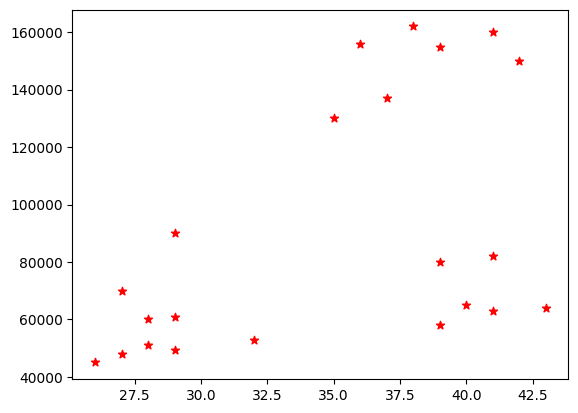

In [ ]:
import matplotlib.pyplot as plt


plt.scatter(df.Age, df['Income($)'], color = 'red', marker = '*')
plt.show()

In [ ]:
#kmporting our unsupervised clustering method
from sklearn.cluster import KMeans


km = KMeans(n_clusters = 3)
y_pred = km.fit_predict(df.drop(columns = 'Name'))
df['cluster'] = y_pred
df

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


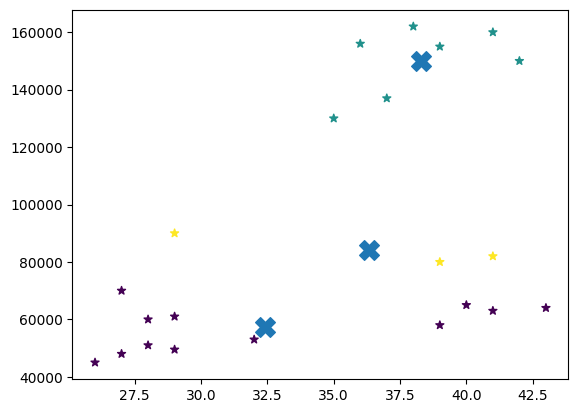

In [ ]:
plt.scatter(df.Age, df['Income($)'], c = df['cluster'], cmap = 'viridis', marker = '*')
plt.scatter(km.cluster_centers_[: , 0], km.cluster_centers_[:, 1], s = 200, marker = 'X')


In [ ]:
#MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Income($)'] = scaler.fit_transform(df[['Income($)']])
df['Age'] = scaler.fit_transform(df[['Age']])

In [ ]:
km = KMeans(n_clusters = 3)
y_pred = km.fit_predict(df.drop(columns = ['Name', 'cluster']))
df['cluster'] = y_pred
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,2
5,Gautam,0.764706,0.940171,2
6,David,0.882353,0.982906,2
7,Andrea,0.705882,1.000000,2
8,Brad,0.588235,0.948718,2
9,Angelina,0.529412,0.726496,2


In [ ]:
km.cluster_centers_

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

Text(0, 0.5, 'income')

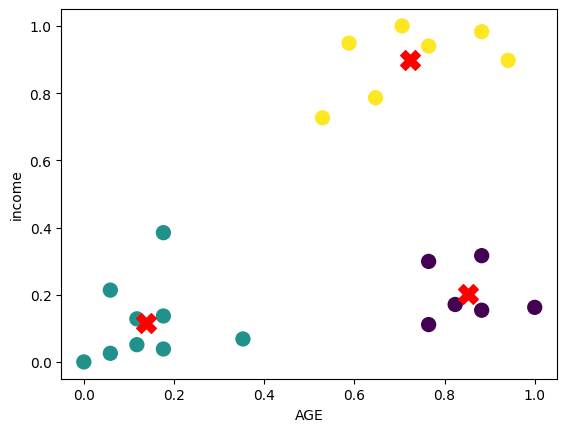

In [ ]:
plt.scatter(df.Age, df['Income($)'], c = df['cluster'], cmap = 'viridis', s = 100)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], c = 'red', marker = 'X', s = 200)
plt.xlabel('AGE')
plt.ylabel("income")


In [ ]:
#elbow Method

k_rng = range(1,10)
sse = []

for k in k_rng:
  km = KMeans(n_clusters = k)
  km.fit(df.drop(columns = 'Name'))
  sse.append(km.inertia_)


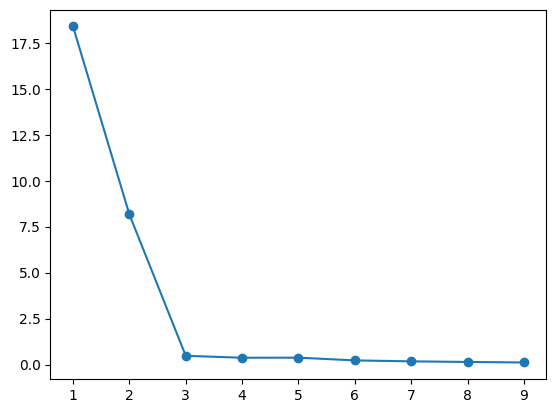

In [ ]:
plt.scatter(k_rng, sse)
plt.plot(k_rng, sse)

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [ ]:
iri = pd.DataFrame(iris.data, columns = iris.feature_names)
iri.drop(columns = ['sepal length (cm)',	'sepal width (cm)'], inplace = True)
iri

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


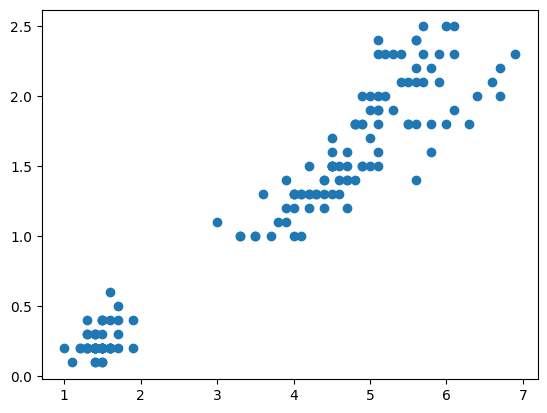

In [ ]:
plt.scatter(iri['petal length (cm)'], iri['petal width (cm)'])

In [ ]:
km = KMeans(n_clusters = 3)
y_pred = km.fit_predict(iri[['petal length (cm)', 'petal width (cm)']])
iri['cluster'] = y_pred
iri

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0
...,...,...,...
145,5.2,2.3,1
146,5.0,1.9,1
147,5.2,2.0,1
148,5.4,2.3,1


In [ ]:
km.cluster_centers_

array([[1.462     , 0.246     ],
       [5.59583333, 2.0375    ],
       [4.26923077, 1.34230769]])

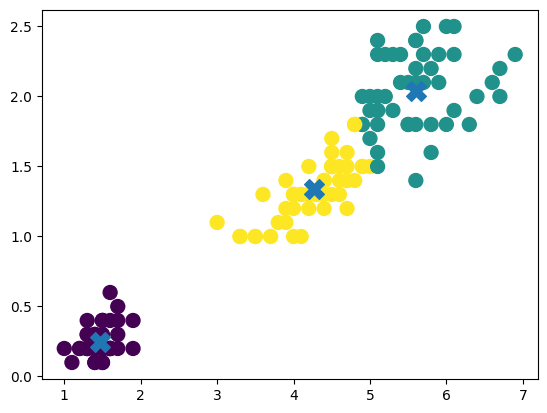

In [ ]:
plt.scatter(iri['petal length (cm)'], iri['petal width (cm)'], c = iri['cluster'], cmap = 'viridis', s = 100)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker = 'X', s = 200)

In [ ]:
k_rng = range(1, 8)
sse = []

for k in k_rng:
  km = KMeans(n_clusters = k)
  km.fit(iri.drop(columns = 'cluster'))
  sse.append(km.inertia_)


In [ ]:
sse

[550.8953333333333,
 86.39021984551391,
 31.412885668276974,
 19.48300089968511,
 13.91690875790876,
 11.150432624668317,
 9.719968251349377]

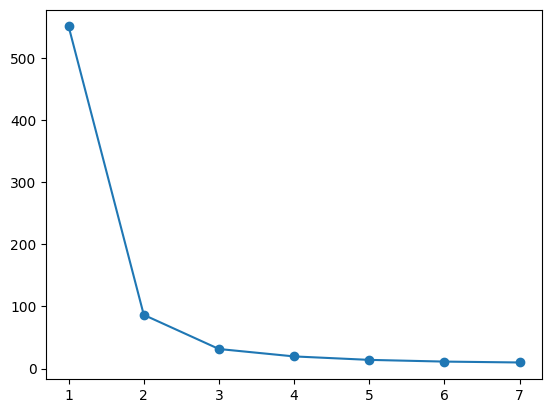

In [ ]:
plt.plot(k_rng, sse)
plt.scatter(k_rng, sse)